In [1]:
from pyns.nsfile import NSFile
from pathlib import Path
import numpy as np
import pandas as pd
import smile_extract
import matplotlib.pyplot as plt
import seaborn as sns
from src.process_ripple import compose_ripple_smile
from src.time_slice import get_epoch_data, multivalue_xs, get_index_level

In [2]:
monkey = "Prez"
date = "2025-12-08"
task = "memory-guided-reach-stim"
folder = Path(f"/Users/raeed/Library/CloudStorage/OneDrive-UniversityofPittsburgh/0-projects/cortex-stim/data/{monkey}/{date}")
nev_filename = folder / f"{monkey}_{date}_{task}_neural.nev"
smile_file = folder / f"{monkey}_{date}_{task}_behavior.mat"
nsfile = NSFile(str(nev_filename))
smile_data = smile_extract.direct_load_smile_data(str(smile_file))

In [3]:
trialframe = compose_ripple_smile(
    nsfile,
    smile_data,
    bin_size='1ms',
    monkey=monkey,
    start_target_name='touchbarcircle',
    end_target_name='reachtargettouchbarmg',
)
trialframe

/Users/raeed/codebase/0-projects/smile-extraction/smile_extract/composition.py:61: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  return pd.concat(
/Users/raeed/codebase/0-projects/smile-extraction/smile_extract/composition.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(


signal                                                                                                  hand position  \
channel                                                                                                             x   
trial_id time                   stim trial result  target direction state            stimulated channel                 
1        0 days 00:00:00        True       failure 180              Reach to Center  (PMd.chan120)          29.530802   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (PMd.chan120)          29.531047   
         0 days 00:00:00.002000 True       failure 180              Reach to Center  (PMd.chan120)          29.531605   
         0 days 00:00:00.003000 True       failure 180              Reach to Center  (PMd.chan120)          29.532397   
         0 days 00:00:00.004000 True       failure 180              Reach to Center  (PMd.chan120)          29.533317   
...                                                                                                               ...   
1180     0 days 00:00:05.995000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:05.996000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:05.997000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:05.998000 True       failure 180              Failure (Center) ()                           NaN   
         0 days 00:00:05.999000 True       failure 180              end              ()                           NaN   

signal                                                                                                             \
channel                                                                                                         y   
trial_id time                   stim trial result  target direction state            stimulated channel             
1        0 days 00:00:00        True       failure 180              Reach to Center  (PMd.chan120)       3.523947   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (PMd.chan120)       3.521966   
         0 days 00:00:00.002000 True       failure 180              Reach to Center  (PMd.chan120)       3.519738   
         0 days 00:00:00.003000 True       failure 180              Reach to Center  (PMd.chan120)       3.517406   
         0 days 00:00:00.004000 True       failure 180              Reach to Center  (PMd.chan120)       3.515142   
...                                                                                                           ...   
1180     0 days 00:00:05.995000 True       failure 180              Failure (Center) ()                       NaN   
         0 days 00:00:05.996000 True       failure 180              Failure (Center) ()                       NaN   
         0 days 00:00:05.997000 True       failure 180              Failure (Center) ()                       NaN   
         0 days 00:00:05.998000 True       failure 180              Failure (Center) ()                       NaN   
         0 days 00:00:05.999000 True       failure 180              end              ()                       NaN   

signal                                                                                                              \
channel                                                                                                          z   
trial_id time                   stim trial result  target direction state            stimulated channel              
1        0 days 00:00:00        True       failure 180              Reach to Center  (PMd.chan120)      -61.147615   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (PMd.chan120)      -61.149474   
         0 days 00:00:00.002000 True       failure 180              Reach to

In [4]:
neural_data = (
    pd.DataFrame(trialframe['neural activity'])
    .rename_axis('recorded channel',axis=1)
    .sort_index(axis=1)
)

pass
False    86
True     42
Name: count, dtype: int64

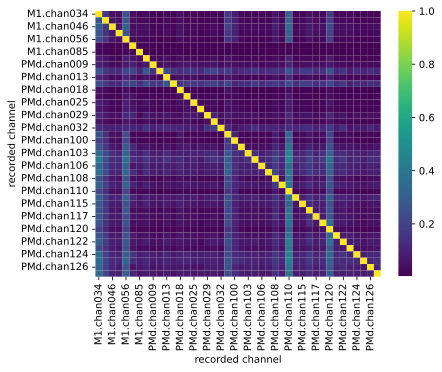

In [5]:
from src.process_ripple import get_channel_stats
spike_mat = (
    neural_data
    .xs(level='stim trial',key=False)
)
channel_stats = get_channel_stats(spike_mat, max_fano=1000, max_coincidence=0.5)
spike_mat_select = (
    spike_mat
    .loc[:, channel_stats.index[channel_stats['pass']]]
    .fillna(0) # sometimes there's missing data, maybe from some packet drops in Trellis?
)
select_coincidence = (
    (spike_mat_select.T @ spike_mat_select)
    / spike_mat_select.sum(axis=0)
)
sns.heatmap(select_coincidence, cmap='viridis')
channel_stats['pass'].value_counts()

In [6]:
stim_response = (
    neural_data
    [channel_stats.index[channel_stats['pass']]]
    .pipe(get_epoch_data,{
        'pre-stim': ('stim',slice(pd.to_timedelta('-200ms'),pd.to_timedelta('-50ms'))),
        'post-stim': ('stim',slice(pd.to_timedelta('200ms'),pd.to_timedelta('350ms'))),
    })
    .div(1e-3)  # convert to firing rate in Hz
    .groupby(['trial_id','stimulated channel','phase'],observed=True)
    .mean()
)
stim_response

recorded channel                       M1.chan034  M1.chan036  M1.chan046  \
trial_id stimulated channel phase                                           
1        (PMd.chan120)      post-stim         0.0    0.000000   13.245033   
                            pre-stim          0.0    0.000000   19.867550   
2        (PMd.chan124)      post-stim         0.0    6.622517   19.867550   
                            pre-stim          0.0    6.622517   13.245033   
3        (PMd.chan016)      post-stim         0.0    0.000000   13.245033   
...                                           ...         ...         ...   
1177     ()                 pre-stim          0.0    0.000000   13.245033   
1178     (PMd.chan123)      post-stim         0.0    0.000000    6.622517   
                            pre-stim          0.0    0.000000    6.622517   
1179     (PMd.chan120)      post-stim         0.0    0.000000   13.245033   
                            pre-stim          0.0   19.867550    6.622517   

recorded channel                       M1.chan050  M1.chan056  M1.chan083  \
trial_id stimulated channel phase                                           
1        (PMd.chan120)      post-stim   13.245033         0.0         0.0   
                            pre-stim    13.245033         0.0         0.0   
2        (PMd.chan124)      post-stim   26.490066         0.0         0.0   
                            pre-stim    52.980132         0.0         0.0   
3        (PMd.chan016)      post-stim   13.245033         0.0         0.0   
...                                           ...         ...         ...   
1177     ()                 pre-stim     6.622517         0.0         0.0   
1178     (PMd.chan123)      post-stim   13.245033         0.0         0.0   
                            pre-stim     6.622517         0.0         0.0   
1179     (PMd.chan120)      post-stim    0.000000         0.0         0.0   
                            pre-stim    13.245033         0.0         0.0   

recorded channel                       M1.chan085  PMd.chan006  PMd.chan009  \
trial_id stimulated channel phase                                             
1        (PMd.chan120)      post-stim    0.000000     0.000000    13.245033   
                            pre-stim     0.000000     0.000000     6.622517   
2        (PMd.chan124)      post-stim    6.622517     0.000000     6.622517   
                            pre-stim     6.622517    26.490066    26.490066   
3        (PMd.chan016)      post-stim    0.000000     0.000000     0.000000   
...                                           ...          ...          ...   
1177     ()                 pre-stim     0.000000     0.000000     0.000000   
1178     (PMd.chan123)      post-stim    0.000000     0.000000     6.622517   
                            pre-stim     0.000000     0.000000     6.622517   
1179     (PMd.chan120)      post-stim   13.245033    52.980132    66.225166   
                            pre-stim     6.622517     6.622517    52.980132   

recorded channel                       PMd.chan010  ...  PMd.chan117  \
trial_id stimulated channel phase                   ...                
1        (PMd.chan120)      post-stim   112.582781  ...     0.000000   
                            pre-stim     59.602649  ...     6.622517   
2        (PMd.chan124)      post-stim    79.470199  ...     0.000000   
                            pre-stim    311.258278  ...     0.000000   
3        (PMd.chan016)      post-stim    33.112583  ...     0.000000   
...                                            ...  ...          ...   
1177     ()                 pre-stim      0.000000  ...     0.000000   
1178     (PMd.chan123)      post-stim     6.622517  ...     0.000000   
                            pre-stim     19.867550  ...     0.000000   
1179     (PMd.chan120)      post-stim   238.410596  ...    26.490066   
                            pre-stim    218.543046  ...    79.470199   

recorded channel               

In [7]:
post_stim = stim_response.xs('post-stim',level='phase')
pre_stim = stim_response.xs('pre-stim',level='phase')
stim_change = (post_stim - pre_stim) # change this to z-score by the non-stim trials

null_stim_response = (
    stim_change
    .xs(level='stimulated channel',key=frozenset())
)

norm_stim_response = (
    stim_change
    .loc[lambda df: df.index.get_level_values('stimulated channel') != frozenset()]
    .sub(null_stim_response.mean())
    .div(null_stim_response.std())
)
import altair as alt
temp = (
    norm_stim_response
    .stack()
    .to_frame('stimulation response (z-score)') # type: ignore
    .groupby(['stimulated channel','recorded channel'],observed=True)
    .mean()
    .reset_index()
    .assign(**{
        # 'recorded channel': lambda df: df['recorded channel'].astype(str),
        'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
    })
)
alt.Chart(temp).mark_rect().encode(
    x=alt.X('recorded channel:N', title='Recorded Channel'),
    y=alt.Y('stimulated channel:N', title='Stimulated Channel'),
    color=alt.Color('stimulation response (z-score):Q', scale=alt.Scale(scheme='redblue', domainMid=0, reverse=True, domain=[-2.5,1.5]), title='firing rate change (z-score)'),
    tooltip=['stimulated channel', 'recorded channel', 'stimulation response (z-score)']
).properties(
    width=400,
    height=400,
)

alt.Chart(...)

In [8]:
stim_raster = (
    neural_data
    [channel_stats.index[channel_stats['pass']]]
    .pipe(get_epoch_data,{
        # for some reason, the stim event is around 85ms after the actual stim time
        'peri-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('350ms'))),
    })
)
stim_raster

recorded channel                                                                                                     M1.chan034  \
trial_id time                     stim trial result  target direction state            stimulated channel phase                   
1        -1 days +23:59:59.750000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.751000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.752000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.753000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.754000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
...                                                                                                                         ...   
1179     0 days 00:00:00.346000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.347000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.348000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.349000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.350000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   

recorded channel                                                                                                     M1.chan036  \
trial_id time                     stim trial result  target direction state            stimulated channel phase                   
1        -1 days +23:59:59.750000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.751000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.752000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.753000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.754000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
...                                                                                                                         ...   
1179     0 days 00:00:00.346000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.347000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.348000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.349000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   
         0 days 00:00:00.350000   True       failure 0                Failure (Center) (PMd.chan120)      peri-stim           0   

recorded channel                                                                                                     M1.chan046  \
trial_id time                     stim trial result  target direction state            stimulated channel phase                   
1        -1 days +23:59:59.750000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.751000 True       failure 180              Reach Target On  (PMd.chan120)      peri-stim           0   
         -1 days +23:59:59.752000 True       failure 180            

In [9]:
def plot_raster(stim_chan_label, rec_chan_label):
    raster = (
        alt.Chart(
            stim_raster
            [rec_chan_label]
            .xs(level='stimulated channel',key=stim_chan_label)
            .reset_index()
            .loc[lambda df: df[rec_chan_label]>0]
            .assign(**{
                'time': lambda df: df['time'].dt.total_seconds()
            })
        )
        .mark_tick()
        .encode(
            x='time:Q',
            y='trial_id:O',
            color='target direction:N',
        )
    )
    return raster

plot_raster(frozenset({'PMd.chan010'}), 'M1.chan034') # & plot_raster('PMd.chan052', 'M1.chan126')

alt.Chart(...)

In [10]:
def plot_nonstim_raster(rec_chan_label):
    raster = (
        alt.Chart(
            stim_raster
            [rec_chan_label]
            .xs(level='stimulated channel',key=frozenset())
            .reset_index()
            .loc[lambda df: df[rec_chan_label]>0]
            .assign(**{
                'time': lambda df: df['time'].dt.total_seconds()
            })
        )
        .mark_tick()
        .encode(
            x='time:Q',
            y='trial_id:O'
        )
    )
    return raster

plot_nonstim_raster('PMd.chan118')

alt.Chart(...)

In [11]:
tf = (
    neural_data
    [channel_stats.index[channel_stats['pass']]]
    .fillna(0) # sometimes there's missing data, maybe from some packet drops in Trellis?
    .xs(level='result',key='success')
    .pipe(get_epoch_data,{
        'pre-stim': ('stim',slice(pd.to_timedelta('-200ms'),pd.to_timedelta('-50ms'))),
        'post-stim': ('stim',slice(pd.to_timedelta('200ms'),pd.to_timedelta('350ms'))),
        # 'peri-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('350ms'))),
        # 'move': ('move',slice(pd.to_timedelta('0ms'),pd.to_timedelta('900ms'))),
        'pre-go': ('Cheat Period',slice(pd.to_timedelta('-200ms'),pd.to_timedelta('0ms'))),
    })
    .div(1e-3)  # convert to firing rate in Hz
    .groupby(['trial_id','phase'])
    .transform(
        smile_extract.smooth_data,
        dt=1e-3,
        std=pd.to_timedelta('10ms').total_seconds(),
        backend='convolve',
    )
    # .groupby(['trial_id','target direction','stimulated channel','phase'])
    # .resample('50ms', level='time')
    # .mean()
)
tf

recorded channel                                                                                                   M1.chan034  \
trial_id time                     stim trial target direction state                   stimulated channel phase                  
3        -1 days +23:59:59.800000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.801000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.802000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.803000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.804000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
...                                                                                                                       ...   
1178     -1 days +23:59:59.996000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         -1 days +23:59:59.997000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         -1 days +23:59:59.998000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         -1 days +23:59:59.999000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         0 days 00:00:00          True       180              Cheat Period            (PMd.chan123)      pre-go           0.0   

recorded channel                                                                                                   M1.chan036  \
trial_id time                     stim trial target direction state                   stimulated channel phase                  
3        -1 days +23:59:59.800000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.801000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.802000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.803000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
         -1 days +23:59:59.804000 True       180              Reach Target On         (PMd.chan016)      pre-stim         0.0   
...                                                                                                                       ...   
1178     -1 days +23:59:59.996000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         -1 days +23:59:59.997000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         -1 days +23:59:59.998000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         -1 days +23:59:59.999000 True       180              Center Hold 2 post-stim (PMd.chan123)      pre-go           0.0   
         0 days 00:00:00          True       180              Cheat Period            (PMd.chan123)      pre-go           0.0   

recorded channel                                                                                                   M1.chan046  \
trial_id time                     stim trial target direction state                   stimulated channel phase                  
3        -1 days +23:59:59.800000 True       180              Reach Target On         (PMd.chan016)      pre-stim    0.000000   
         -1 days +23:59:59.801000 True       180              Reach Target On         (PMd.chan016)      pre-stim    0.000000   
         -1 days +23:59:59.802000 True       180              Reach Target On         (PMd.chan016)      pre-stim    0.000000   

In [12]:
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.utils.validation import check_is_fitted
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from src.time_slice import get_index_level, multivalue_xs

class SoftnormScaler(TransformerMixin, BaseEstimator):
    def __init__(self, norm_const=5):
        self.norm_const = norm_const

    def fit(self,X,y=None):
        def get_range(arr,axis=None):
            return np.nanmax(arr,axis=axis)-np.nanmin(arr,axis=axis)
        self.activity_range_ = get_range(X,axis=0)
        return self

    def transform(self,X):
        check_is_fitted(self, 'activity_range_')
        return X / (self.activity_range_ + self.norm_const)

class DataFrameTransformer(TransformerMixin, BaseEstimator):
    def __init__(self, transformer):
        self.transformer = transformer

    def fit(self,X,y=None):
        self.transformer.fit(X,y)
        return self

    def transform(self, X):
        output = self.transformer.transform(X)
        return pd.DataFrame(
            output,
            index=X.index,
            columns=range(output.shape[1]),
        )


pipeline = make_pipeline(
    SoftnormScaler(norm_const=5),
    DataFrameTransformer(PCA(n_components=4))
    # DataFrameTransformer(LinearDiscriminantAnalysis())
)

pipeline.fit(
    (
        tf
        .xs(level='stimulated channel',key=frozenset())
        .xs(level='phase',key='pre-go')
        .groupby(['trial_id','target direction'])
        .mean()
    ),
    (
        tf
        .xs(level='stimulated channel',key=frozenset())
        .xs(level='phase',key='pre-go')
        .groupby(['trial_id','target direction'])
        .mean()
        .pipe(get_index_level, 'target direction')
    ),
)

tf_pca = pipeline.transform(tf)


alt.data_transformers.enable('json')
(
    alt.Chart(
        tf_pca
        .groupby(['trial_id','target direction','phase','stimulated channel'],observed=True)
        .mean()
        .pipe(multivalue_xs,level='phase',keys=['pre-stim','post-stim']) # type: ignore
        .pipe(multivalue_xs,level='stimulated channel',keys=[
            frozenset(),
            frozenset({'PMd.chan010'}),
            frozenset({'PMd.chan118'}),
            frozenset({'M1.chan085'}),
        ]) # type: ignore
        # .xs(level='stimulated channel',key=frozenset())
        .rename(columns=lambda x: f'PCA Dimension {x+1}')
        .reset_index()
        # .assign(
        #     time=lambda df: df['time'].dt.total_seconds(),
        # )
        # .assign(**{
        #     # 'recorded channel': lambda df: df['recorded channel'].astype(str),
        #     'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x))),
        # })
    )
    .mark_point(filled=True, size=100, opacity=0.7)
    .encode(
        x='PCA Dimension 1',
        y='PCA Dimension 2',
        color='target direction:N',
        row = 'stimulated channel:N',
        # row=alt.Row('stimulated channel:N', sort=[frozenset(), frozenset({'PMd.chan018','PMd.chan100'})]),
        column=alt.Column('phase:N', sort=['pre-stim', 'post-stim']),
        # tooltip=['trial_id','target direction','time'],
        detail='trial_id:N',
        # order='time:Q',
    )
)

/opt/homebrew/Caskroom/mambaforge/base/envs/miso-analysis/lib/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


alt.Chart(...)

In [13]:
# calculate spread change...
variance_ratio = (
    tf_pca
    .groupby(['stimulated channel','phase'],observed=True)
    .filter(lambda x: x.shape[0] > 9)
    .groupby(['stimulated channel','phase'],observed=True)
    .var()
    .sum(axis=1)
    .unstack(level='phase')
    .assign(**{
        'variance ratio': lambda df: df['post-stim'] / df['pre-stim']
    })
    ['variance ratio']
)

(
    alt.Chart(
        variance_ratio
        .reset_index()
    )
    .mark_bar()
    .encode(
        y=alt.Y('stimulated channel:N', title='Stimulated Channel'),
        x=alt.X('variance ratio:Q', title='Post-Stim / Pre-Stim Variance Ratio'),
        tooltip=['stimulated channel', 'variance ratio']
    )
)

alt.Chart(...)

In [14]:
from src.process_ripple import read_map
electrode_map = (
    # read_map(Path('../data/sulley/sulley_SN_4566-004410.map'))
    read_map(Path('../data/prez/prez_SN_4566-002444.map'))
    [['x','y']]
    .sort_index()
)
example_stim_response = (
    norm_stim_response
    .pipe(multivalue_xs,level='stimulated channel',keys=[
        frozenset(),
        frozenset({'PMd.chan125'}),
        frozenset({'PMd.chan113'}),
        frozenset({'PMd.chan123'}),
        frozenset({'PMd.chan022'}),
    ]) # type: ignore
    .stack()
    .to_frame('stimulation response (z-score)') # type: ignore
    .groupby(['recorded channel','stimulated channel'],observed=True)
    .mean()
    .join(electrode_map.rename_axis('recorded channel'), how='left')
    .reset_index()
)
alt.Chart(example_stim_response).mark_rect().encode(
    x=alt.X('x:O', title='X Coordinate'),
    y=alt.Y('y:O', title='Y Coordinate'),
    color=alt.Color('stimulation response (z-score):Q', scale=alt.Scale(scheme='redblue', domainMid=0, reverse=True, domain=[-2.5,1.5]), title='Z-scored Change in Firing Rate'),
    row='stimulated channel:N',
    tooltip=['recorded channel', 'stimulation response (z-score)', 'x', 'y']
).properties(
    width=650,
    height=400,
)

alt.Chart(...)

In [15]:
import altair as alt
alt.data_transformers.enable('json')
hand_data = trialframe['hand position']
movement = (
    hand_data
    .xs(level='result',key='success')
    .pipe(multivalue_xs,level='stimulated channel',keys=[frozenset(),frozenset({'PMd.chan010'})])
    .pipe(get_epoch_data,epochs={
        'peri-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('600ms'))),
        'pre-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('-50ms'))),
    })
)

reference_movement = (
    movement
    .xs(level='phase',key='pre-stim')
    .groupby('trial_id')
    .mean()
)

base_chart = (
    alt.Chart(
        (movement-reference_movement)
        .stack()
        .rename('position')
        .reset_index()
        .assign(
            time=lambda df: df['time'].dt.total_seconds(),
        )
        .assign(**{
            'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
        })
    )
    # .configure_axis(grid=False)
    # .configure_view(stroke=None)
)
traces = (
    base_chart
    .mark_errorband(extent='ci')
    # .mark_line()
    .encode(
        x='time:Q',
        y=alt.Y('position:Q',scale=alt.Scale(zero=False)),
        # detail='trial_id:O',
        color=alt.Color('stimulated channel:N',sort=['PMd.chan010','set()']),
    )
)

(
    traces
    .facet(
        # row='target direction:N',
        column='channel:N',
    )
    .configure_axis(grid=False)
    .configure_view(stroke=None)
)

alt.FacetChart(...)

In [16]:
smile_extract.get_state_target_table(smile_data[0])

,window,x,y,z,radius,height,depth
state,target,,,,,,
Reach to Center,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
Center Hold,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
Reach Target On,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
Center Hold 2 pre-stim,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
stim,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
Center Hold 2 post-stim,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
Cheat Period,TouchbarCircle,80.0,895.0,0.0,10.0,NaN,10000.0
Reach to Target,ReachTargetTouchbarMG,10.0,895.0,0.0,4.1,NaN,5000.0
Target Hold,ReachTargetTouchbarMG,10.0,895.0,0.0,4.1,NaN,5000.0


/opt/homebrew/Caskroom/mambaforge/base/envs/miso-analysis/lib/python3.11/site-packages/pandas/core/groupby/grouper.py:392: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  ax = Index(ax._get_level_values(level), name=ax.names[level])


TypeError: Index must be a MultiIndex

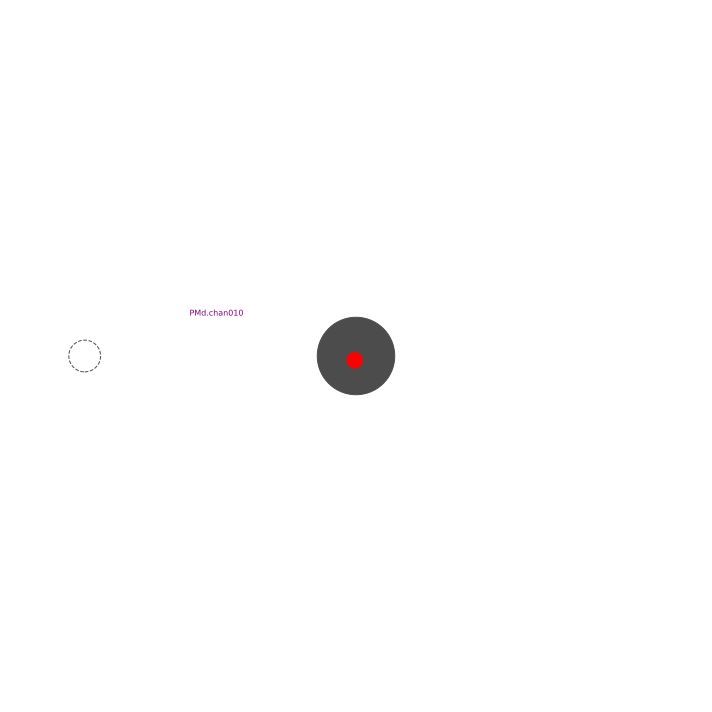

In [22]:
from src.animation import animate_trial

trial_to_animate = 124
trial = (
    trialframe
    .pipe(get_epoch_data,epochs={
        'peri-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('600ms'))),
    })
    .xs(level='trial_id',key=trial_to_animate)
    .xs(level='phase',key='peri-stim')
)
anim = animate_trial(trial, save_path=f'../results/{monkey}_{date}_{task}_trial{trial_to_animate}_peri-stim.mp4')

In [24]:
(
    trial
)

signal                                                                                                  hand position  \
channel                                                                                                             x   
time                     stim trial result  target direction state                   stimulated channel                 
-1 days +23:59:59.750000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)          -0.249143   
-1 days +23:59:59.751000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)          -0.252407   
-1 days +23:59:59.752000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)          -0.254937   
-1 days +23:59:59.753000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)          -0.256627   
-1 days +23:59:59.754000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)          -0.257405   
...                                                                                                               ...   
0 days 00:00:00.596000   True       success 180              Center Hold 2 post-stim (PMd.chan010)           2.433556   
0 days 00:00:00.597000   True       success 180              Center Hold 2 post-stim (PMd.chan010)           2.426962   
0 days 00:00:00.598000   True       success 180              Center Hold 2 post-stim (PMd.chan010)           2.420415   
0 days 00:00:00.599000   True       success 180              Center Hold 2 post-stim (PMd.chan010)           2.413964   
0 days 00:00:00.600000   True       success 180              Center Hold 2 post-stim (PMd.chan010)           2.407655   

signal                                                                                                             \
channel                                                                                                         y   
time                     stim trial result  target direction state                   stimulated channel             
-1 days +23:59:59.750000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)      -1.137309   
-1 days +23:59:59.751000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)      -1.136014   
-1 days +23:59:59.752000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)      -1.134973   
-1 days +23:59:59.753000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)      -1.134235   
-1 days +23:59:59.754000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)      -1.133837   
...                                                                                                           ...   
0 days 00:00:00.596000   True       success 180              Center Hold 2 post-stim (PMd.chan010)       0.105240   
0 days 00:00:00.597000   True       success 180              Center Hold 2 post-stim (PMd.chan010)       0.099236   
0 days 00:00:00.598000   True       success 180              Center Hold 2 post-stim (PMd.chan010)       0.093056   
0 days 00:00:00.599000   True       success 180              Center Hold 2 post-stim (PMd.chan010)       0.086968   
0 days 00:00:00.600000   True       success 180              Center Hold 2 post-stim (PMd.chan010)       0.081216   

signal                                                                                                             \
channel                                                                                                         z   
time                     stim trial result  target direction state                   stimulated channel             
-1 days +23:59:59.750000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)       0.775497   
-1 days +23:59:59.751000 True       success 180              Center Hold 2 pre-stim  (PMd.chan010)       0.776051   
-1 days +23:59:59.752000 True       success 180              Center Hold 2 pre-st

In [ ]:
[1] + list({'a':1, 'b':2}.values())

In [ ]:
movement.xs(level='stimulated channel',key=frozenset({'PMd.chan010'}))

In [ ]:
from src.process_ripple import process_neural_data, trialize_timestamps, get_trial_starts
_, stim_table = process_neural_data(nsfile)
from pyns.nsentity import EntityType
from scipy.signal import butter, sosfiltfilt
stim_chan_label = 'PMd.chan052'
rec_chan_label = 'M1.chan126'

trial_starts = get_trial_starts(nsfile)
stim_times = (
    stim_table
    .pipe(trialize_timestamps, trial_starts)
    .groupby('trial_id')
    .first()
    .set_index('channel', append=True)
)
chan_stims = (
    stim_times
    .xs(level='channel', key=stim_chan_label)
    .assign(timestamp=lambda df: df['timestamp'] + df.index.get_level_values('trial_id').map(trial_starts))
    ['timestamp']
    .apply(lambda ts: ts.total_seconds())
)

chan_signal = [e for e in nsfile.get_entities(EntityType.analog) if e.label == f'{rec_chan_label} raw'][0]
signal_bins = chan_signal.get_index_by_time(1)
raw_signal = chan_signal.get_analog_data(
    start_index=chan_signal.get_index_by_time(chan_stims.values[3]-0.16), # 160 milliseconds before stim
    index_count=chan_signal.get_index_by_time(0.55), # 550 millisecond of data
)

# import matplotlib.pyplot as plt
# fig,ax = plt.subplots(1,1,figsize=(15,5))
# ax = sns.lineplot(lfp_data,ax=ax)
# ax.set_ylim(-200,200)

sos = butter(4, 250, fs=chan_signal.sample_freq, btype='highpass', output='sos')
filt_signal = sosfiltfilt(sos, raw_signal)

fig,ax = plt.subplots(1,1,figsize=(9,3))
ax.plot(np.linspace(-0.25,0.30,len(filt_signal)),filt_signal,color='0.3')
ax.set_ylim(-100,100)
ax.set_xlabel('time (s)')
ax.set_ylabel('filtered signal (uV)')

In [ ]:
from src.impedance import load_and_process_impedance
# Parse the impedance file using the new module
impedance_filename = folder / "Sulley_2025-10-03_impedance.txt"
impedances = (
    load_and_process_impedance(impedance_filename)
    .groupby('Elec')
    ['Mag_kOhms']
    .mean()
    .rename('impedance (kOhms)')
    .rename_axis('channel')
    .to_frame()
    .assign(**{'pass': channel_stats['pass']})
)
sns.displot(
    data=impedances,
    x='impedance (kOhms)',
    hue='pass',
    log_scale=True,
)

In [ ]:
' '.join([
    str.replace('chan00','').replace('chan0','').replace('chan','').replace('M1.','').replace('PMd.','')
    for str in channel_stats.index[channel_stats['pass']]
])

In [ ]:
from src.time_slice import get_index_level
success_rate = (
    trialframe
    .pipe(get_index_level, 'result')
    .groupby(['trial_id','stimulated channel'],observed=True)
    .first()
    .map(lambda x: x == 'success')
    .groupby('stimulated channel',observed=True)
    .mean()
)
success_rate